# Ablation 05: Expert Architecture Diversity

Tests whether a heterogeneous pool of GNN experts (GCN+GAT+SAGE+GIN) outperforms homogeneous pools of a single architecture type, and whether the MoE ensemble beats any single expert trained alone.

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
DRIVE_DIR    = '/content/drive/MyDrive/GQMoE'
ABLATION_DIR = f'{DRIVE_DIR}/ablations/05_expert_diversity'
DATA_DIR     = f'{DRIVE_DIR}/data'
os.makedirs(ABLATION_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
requirements_path = f"{DRIVE_DIR}/requirements.txt"
!pip install -r "{requirements_path}"

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 27.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 50.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 34.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 

In [ ]:
import os, json, math, torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import knn_graph, global_mean_pool, GlobalAttention, GCNConv, GATConv, SAGEConv, GINConv
from torchvision import transforms
from sklearn.metrics import roc_auc_score
import pennylane as qml
torch.manual_seed(42); np.random.seed(42)


In [ ]:
config = {
    "file_path": f"{DATA_DIR}/retinamnist.npz",
    "patch_size": 7, "k_neighbors": 3, "batch_size": 32,
    "n_qubits": 8, "n_layers": 2, "expert_hidden": 64, "expert_out": 128,
    "top_k": 2, "n_iterations": 3, "n_classes": 5, "clf_hidden": 256,
    "dropout": 0.3, "epochs": 50, "warmup_epochs": 5,
    "lr": 1e-3, "weight_decay": 1e-4,
    "aug_hflip": True, "aug_vflip": True, "aug_rotation": 15,
}


## Data Pipeline

In [ ]:
class MedMNISTGraphPipeline:
    def __init__(self,ps,k): self.ps=ps; self.k=k
    def process(self, img):
        c,h,w=img.shape; p=self.ps
        patches=img.unfold(1,p,p).unfold(2,p,p); n=patches.shape[1]*patches.shape[2]
        x=patches.contiguous().view(c,n,p*p).permute(1,0,2).reshape(n,-1)
        return Data(x=x, edge_index=knn_graph(x,k=self.k,loop=False))

class NPZDataset(Dataset):
    def __init__(self,path,split,pl,tf=None):
        self.pl=pl; self.tf=tf; d=np.load(path)
        self.imgs=d[f'{split}_images']; self.labs=d[f'{split}_labels']
    def __len__(self): return len(self.imgs)
    def __getitem__(self,i):
        img=torch.from_numpy(self.imgs[i]).float().permute(2,0,1)/255.
        if self.tf: img=self.tf(img)
        g=self.pl.process(img); lv=self.labs[i]; lv=lv.item() if lv.size==1 else lv[0]
        g.y=torch.tensor([lv],dtype=torch.long); return g

def build_tf(c):
    a=[]
    if c.get("aug_hflip"): a.append(transforms.RandomHorizontalFlip())
    if c.get("aug_vflip"): a.append(transforms.RandomVerticalFlip())
    if c.get("aug_rotation",0)>0: a.append(transforms.RandomRotation(c["aug_rotation"]))
    return transforms.Compose(a) if a else None

pl           = MedMNISTGraphPipeline(config["patch_size"], config["k_neighbors"])
train_loader = DataLoader(NPZDataset(config["file_path"],'train',pl,build_tf(config)), config["batch_size"], shuffle=True)
val_loader   = DataLoader(NPZDataset(config["file_path"],'val',  pl), config["batch_size"])
test_loader  = DataLoader(NPZDataset(config["file_path"],'test', pl), config["batch_size"])
feature_dim  = next(iter(train_loader)).x.shape[1]
print(f"feature_dim: {feature_dim}")


feature_dim: 147


## Expert Pool Factories

Each factory returns 8 experts of a given type with varied widths (to keep parameter counts comparable).

In [ ]:
def make_gcn_experts(fd, h, o, n=8):
    """n GCN experts with alternating narrow/wide widths."""
    class GCN(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1,self.c2=GCNConv(i,hi),GCNConv(hi,oo)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    widths = [h if i%2==0 else h*2 for i in range(n)]
    return [GCN(fd,w,o) for w in widths]

def make_gat_experts(fd, h, o, n=8):
    class GAT(nn.Module):
        def __init__(self,i,hi,oo,hd): super().__init__(); self.c1=GATConv(i,hi,heads=hd,concat=True); self.c2=GATConv(hi*hd,oo,heads=1,concat=False)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    heads = [4,4,4,4,8,8,8,8][:n]
    return [GAT(fd,h,o,hd) for hd in heads]

def make_sage_experts(fd, h, o, n=8):
    class SAGE(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1,self.c2=SAGEConv(i,hi),SAGEConv(hi,oo)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    widths=[h if i%2==0 else h*2 for i in range(n)]
    return [SAGE(fd,w,o) for w in widths]

def make_gin_experts(fd, h, o, n=8):
    class GIN(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1=GINConv(nn.Sequential(nn.Linear(i,hi),nn.ReLU(),nn.Linear(hi,hi))); self.c2=GINConv(nn.Sequential(nn.Linear(hi,oo),nn.ReLU(),nn.Linear(oo,oo)))
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    widths=[h if i%2==0 else h*2 for i in range(n)]
    return [GIN(fd,w,o) for w in widths]

def make_mixed_experts(fd, h, o):
    class GCN(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1,self.c2=GCNConv(i,hi),GCNConv(hi,oo)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    class GAT(nn.Module):
        def __init__(self,i,hi,oo,hd): super().__init__(); self.c1=GATConv(i,hi,heads=hd,concat=True); self.c2=GATConv(hi*hd,oo,heads=1,concat=False)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    class SAGE(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1,self.c2=SAGEConv(i,hi),SAGEConv(hi,oo)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    class GIN(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1=GINConv(nn.Sequential(nn.Linear(i,hi),nn.ReLU(),nn.Linear(hi,hi))); self.c2=GINConv(nn.Sequential(nn.Linear(hi,oo),nn.ReLU(),nn.Linear(oo,oo)))
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    return [GCN(fd,h,o),GCN(fd,h*2,o),GAT(fd,h,o,4),GAT(fd,h,o,8),SAGE(fd,h,o),SAGE(fd,h*2,o),GIN(fd,h,o),GIN(fd,h*2,o)]


## Full GQMoE Model with Pluggable Expert Pool

In [ ]:
def make_quantum_router(fd, nq, nl):
    class QR(nn.Module):
        def __init__(self):
            super().__init__(); self.enc=nn.Sequential(nn.Linear(fd,nq),nn.Tanh())
            dev=qml.device("default.qubit",wires=nq)
            @qml.qnode(dev,interface="torch",diff_method="backprop")
            def c(inputs,weights):
                qml.AngleEmbedding(inputs*math.pi,wires=range(nq),rotation="Y")
                for l in range(nl):
                    for q in range(nq): qml.RY(weights[l,q],wires=q)
                    for q in range(nq): qml.CNOT(wires=[q,(q+1)%nq])
                return [qml.expval(qml.PauliZ(q)) for q in range(nq)]
            self.vqc=qml.qnn.TorchLayer(c,{"weights":(nl,nq)})
        def forward(self,g): return torch.softmax(self.vqc(self.enc(g)),-1)
    return QR()

class GQMoEWithExperts(nn.Module):
    def __init__(self, experts, fd, cfg):
        super().__init__()
        self.router=make_quantum_router(fd, cfg["n_qubits"], cfg["n_layers"])
        self.experts=nn.ModuleList(experts); self.top_k=cfg["top_k"]; self.n_iter=cfg["n_iterations"]
        self.upd=nn.ModuleList([nn.Sequential(nn.Linear(cfg["expert_out"],fd),nn.LayerNorm(fd)) for _ in range(1)])
        self.proj=nn.Linear(cfg["expert_out"],fd); self.norm=nn.LayerNorm(fd)
        self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(fd,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))
        self.clf=nn.Sequential(nn.Linear(fd,cfg["clf_hidden"]),nn.ReLU(),nn.Dropout(cfg["dropout"]),nn.Linear(cfg["clf_hidden"],cfg["n_classes"]))

    def moe_forward(self, bd, rw):
        tv,ti=torch.topk(rw,self.top_k,-1); sp=torch.zeros_like(rw).scatter_(1,ti,tv); sp/=sp.sum(-1,keepdim=True)
        o=torch.stack([e(bd.x,bd.edge_index,bd.batch) for e in self.experts],1)
        return (sp.unsqueeze(-1)*o).sum(1)

    def forward(self, bd):
        b=bd.clone()
        for i in range(self.n_iter):
            g=global_mean_pool(b.x,b.batch); rw=self.router(g); mo=self.moe_forward(b,rw)
            if i<self.n_iter-1: b.x=self.norm(b.x+self.proj(mo[b.batch]))
        return self.clf(self.pool(b.x,b.batch))


## Training & Evaluation

In [ ]:
@torch.no_grad()
def evaluate(model, loader, crit, device):
    model.eval(); ls,c,tot=0.,0,0; p,l=[],[]
    for b in loader:
        b=b.to(device); lg=model(b); lb=b.y.squeeze()
        ls+=crit(lg,lb).item()*b.num_graphs; c+=(lg.argmax(-1)==lb).sum().item(); tot+=b.num_graphs
        p.append(torch.softmax(lg,-1).cpu()); l.append(lb.cpu())
    pr=torch.cat(p).numpy(); lb=torch.cat(l).numpy()
    auc=roc_auc_score(lb,pr,multi_class="ovr",average="macro") if len(np.unique(lb))>1 else float("nan")
    return ls/tot, c/tot, auc

def train_model(model, name, save_dir):
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"); model=model.to(device)
    crit=nn.CrossEntropyLoss(); opt=torch.optim.Adam(model.parameters(),lr=config["lr"],weight_decay=config["weight_decay"])
    warmup=torch.optim.lr_scheduler.LinearLR(opt,1e-3,1.,config["warmup_epochs"])
    cosine=torch.optim.lr_scheduler.CosineAnnealingLR(opt,config["epochs"]-config["warmup_epochs"])
    sched=torch.optim.lr_scheduler.SequentialLR(opt,[warmup,cosine],[config["warmup_epochs"]])
    hist={"val_acc":[],"val_auc":[]}; best=0.

    for ep in range(1, config["epochs"]+1):
        model.train()
        for b in train_loader:
            b=b.to(device); opt.zero_grad(); nn.CrossEntropyLoss()(model(b),b.y.squeeze()).backward(); opt.step()
        sched.step()
        _,va,vau=evaluate(model,val_loader,crit,device)
        hist["val_acc"].append(va); hist["val_auc"].append(vau)
        if va>best: best=va; torch.save(model.state_dict(),f"{save_dir}/best_{name}.pt")
        if ep%10==0 or ep==config["epochs"]:
            print(f"[{name}] ep {ep:03d} | val acc {va:.4f} auc {vau:.4f}")
    with open(f"{save_dir}/hist_{name}.json","w") as f: json.dump(hist,f)
    return hist

h, o = config["expert_hidden"], config["expert_out"]
VARIANTS = {
    "Mixed (GCN+GAT+SAGE+GIN)": make_mixed_experts(feature_dim, h, o),
    "All-GCN":                   make_gcn_experts(feature_dim, h, o),
    "All-GAT":                   make_gat_experts(feature_dim, h, o),
    "All-SAGE":                  make_sage_experts(feature_dim, h, o),
    "All-GIN":                   make_gin_experts(feature_dim, h, o),
}

histories, test_results = {}, {}
for variant_name, experts in VARIANTS.items():
    safe_name = variant_name.lower().replace(" ","_").replace("(","").replace(")","").replace("+","_")
    print(f"\n=== {variant_name} ===")
    model = GQMoEWithExperts(experts, feature_dim, config)
    hist  = train_model(model, safe_name, ABLATION_DIR)
    histories[variant_name] = hist

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(f"{ABLATION_DIR}/best_{safe_name}.pt", map_location=device))
    _,ta,tau = evaluate(model.to(device), test_loader, nn.CrossEntropyLoss(), device)
    test_results[variant_name] = {"acc":ta, "auc":tau}
    print(f"  Test acc: {ta*100:.2f}%  AUC: {tau:.4f}")



=== Mixed (GCN+GAT+SAGE+GIN) ===


/tmp/ipykernel_2424/1734398803.py:24: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(fd,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))


[mixed_gcn_gat_sage_gin] ep 010 | val acc 0.5583 auc 0.8060
[mixed_gcn_gat_sage_gin] ep 020 | val acc 0.6000 auc 0.8196
[mixed_gcn_gat_sage_gin] ep 030 | val acc 0.5667 auc 0.8061
[mixed_gcn_gat_sage_gin] ep 040 | val acc 0.5583 auc 0.8004
[mixed_gcn_gat_sage_gin] ep 050 | val acc 0.5500 auc 0.8136
  Test acc: 53.00%  AUC: 0.7372

=== All-GCN ===


/tmp/ipykernel_2424/1734398803.py:24: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(fd,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))


[all-gcn] ep 010 | val acc 0.6250 auc 0.8214
[all-gcn] ep 020 | val acc 0.5833 auc 0.8034
[all-gcn] ep 030 | val acc 0.6083 auc 0.8135
[all-gcn] ep 040 | val acc 0.5833 auc 0.8104
[all-gcn] ep 050 | val acc 0.5917 auc 0.8074
  Test acc: 53.25%  AUC: 0.7478

=== All-GAT ===


...

[all-gat] ep 010 | val acc 0.5000 auc 0.8019
[all-gat] ep 020 | val acc 0.5500 auc 0.8053
[all-gat] ep 030 | val acc 0.5667 auc 0.8286
[all-gat] ep 040 | val acc 0.5500 auc 0.8020
[all-gat] ep 050 | val acc 0.5917 auc 0.8041
  Test acc: 53.50%  AUC: 0.7401

=== All-SAGE ===


/tmp/ipykernel_2424/1734398803.py:24: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(fd,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))


[all-sage] ep 010 | val acc 0.5917 auc 0.8223
[all-sage] ep 020 | val acc 0.5833 auc 0.7860
[all-sage] ep 030 | val acc 0.5917 auc 0.8180
[all-sage] ep 040 | val acc 0.5583 auc 0.7926
[all-sage] ep 050 | val acc 0.5083 auc 0.7715
  Test acc: 51.25%  AUC: 0.7282

=== All-GIN ===


/tmp/ipykernel_2424/1734398803.py:24: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(fd,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))


[all-gin] ep 010 | val acc 0.5750 auc 0.8095
[all-gin] ep 020 | val acc 0.5750 auc 0.8135
[all-gin] ep 030 | val acc 0.5583 auc 0.8006
[all-gin] ep 040 | val acc 0.5250 auc 0.8140
[all-gin] ep 050 | val acc 0.5167 auc 0.8055
  Test acc: 51.50%  AUC: 0.7271


## Visualization

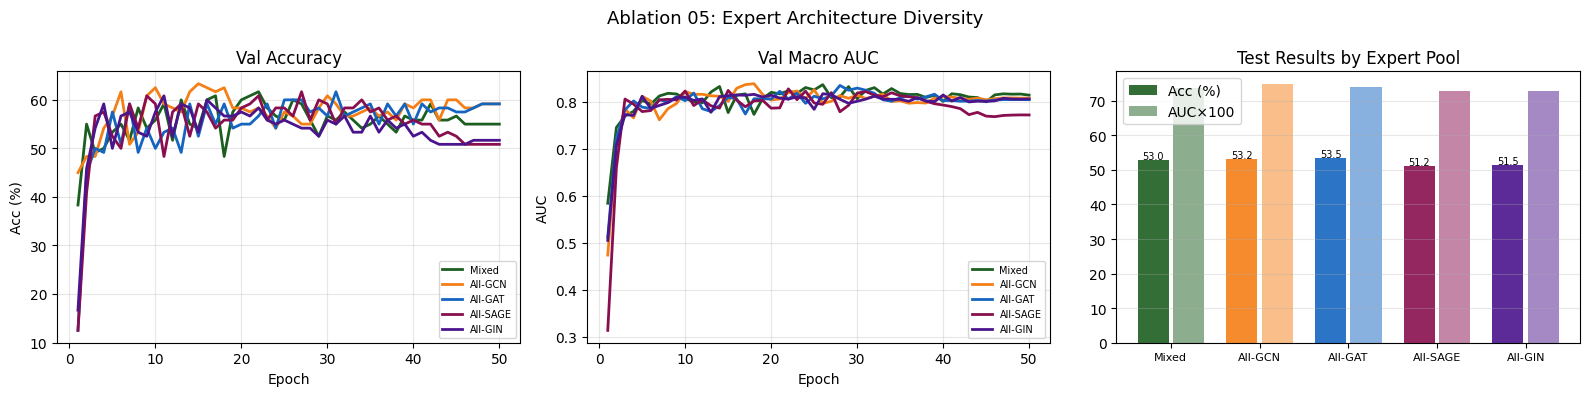


Best: All-GAT — 53.50%


In [ ]:
names  = list(test_results.keys())
colors = ["#1B5E20","#F57F17","#1565C0","#880E4F","#4A148C"]
epochs = range(1, config["epochs"]+1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (n, c) in enumerate(zip(names, colors)):
    h = histories[n]
    axes[0].plot(epochs, [a*100 for a in h["val_acc"]], label=n.split()[0], lw=2, color=c)
    axes[1].plot(epochs, h["val_auc"],                  label=n.split()[0], lw=2, color=c)
for ax, title, yl in [(axes[0],"Val Accuracy","Acc (%)"),(axes[1],"Val Macro AUC","AUC")]:
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(yl); ax.legend(fontsize=7); ax.grid(alpha=0.3)

x = np.arange(len(names))
accs = [test_results[n]["acc"]*100 for n in names]
aucs = [test_results[n]["auc"]*100 for n in names]
axes[2].bar(x-0.2, accs, width=0.35, color=colors, alpha=0.9, label="Acc (%)")
axes[2].bar(x+0.2, aucs, width=0.35, color=colors, alpha=0.5, label="AUC×100")
axes[2].set_xticks(x)
axes[2].set_xticklabels([n.split()[0] for n in names], fontsize=8)
axes[2].set_title("Test Results by Expert Pool"); axes[2].legend(); axes[2].grid(alpha=0.3, axis="y")
for j,(a,u) in enumerate(zip(accs,aucs)):
    axes[2].text(j-0.2, a+0.1, f"{a:.1f}", ha="center", fontsize=7)

plt.suptitle("Ablation 05: Expert Architecture Diversity", fontsize=13)
plt.tight_layout()
plt.savefig(f"{ABLATION_DIR}/ablation05_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nBest: {max(test_results, key=lambda n: test_results[n]['acc'])} — {max(r['acc'] for r in test_results.values())*100:.2f}%")
